In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import Utils as utils


2025-02-03 00:08:49.246018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-03 00:08:49.261723: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-03 00:08:49.266554: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-03 00:08:49.277558: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-03 00:08:50.146444: W tensorflow/compiler/tf2

## Fast Gradient Sign Method (FGSM)

### Overview
FGSM is an adversarial attack technique that creates perturbed inputs to mislead deep learning models. It leverages the gradient of the loss function to generate adversarial examples efficiently.

### Formula
Given:
- `x`: Input  
- `y`: True label  
- `J`: Loss function  
- `epsilon (ε)`: Perturbation magnitude  

The adversarial example `x_adv` is defined as:

x_adv = x + ε * sign(∇_x J(θ, x, y))

### Key Idea
FGSM adds a small perturbation in the direction of the gradient to maximize the model's error.

In [2]:
def fgsm_attack_single_image(model, image, label, epsilon, normalized=True):
    """
    Perform FGSM attack on a single image without normalization.
    
    Args:
        model (tf.keras.Model): Trained model.
        image (tf.Tensor): Input image of shape (H, W, C), values in [0, 255].
        label (tf.Tensor): True label (integer).
        epsilon (float): Perturbation magnitude.
        normalized (bool): Normalized image.

    Returns:
        tf.Tensor: Adversarial example in [0, 255].
    """
    # Adjust epsilon for non normalized images
    if not normalized:
        epsilon = epsilon * 255.0

    # Ensure the image has a batch dimension
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = tf.expand_dims(image, axis=0)  # Add batch dimension

    # Add batch dimension
    label = tf.expand_dims(label, axis=0) 

    with tf.GradientTape() as tape:
        tape.watch(image)
        # Forward pass
        prediction = model(image, training=False)
        # Calculate loss
        loss = tf.keras.losses.sparse_categorical_crossentropy(label, prediction)

    # Calculate gradient of the loss with respect to the input image
    gradient = tape.gradient(loss, image)

    # Get the sign of the gradient
    gradient_sign = tf.sign(gradient)

    # Generate adversarial example
    adversarial_image = image + epsilon * gradient_sign 

    # Clip values to stay in valid range [0, 255]
    if normalized:
        adversarial_image = tf.clip_by_value(adversarial_image, 0, 1)
    else:
        adversarial_image = tf.clip_by_value(adversarial_image, 0, 255)

    return tf.squeeze(adversarial_image)

In [3]:
def pgd_attack_single_image(model, image, label, epsilon, alpha, iterations, normalized=True):
    """
    Perform PGD attack on a single image without normalization.
    
    Args:
        model (tf.keras.Model): Trained model.
        image (tf.Tensor): Input image of shape (H, W, C), values in [0, 255].
        label (tf.Tensor): True label (integer).
        epsilon (float): Maximum perturbation magnitude.
        alpha (float): Step size for each iteration.
        iterations (int): Number of PGD iterations.
        normalized (bool): For normalized images, set to True.

    Returns:
        tf.Tensor: Adversarial example in [0, 255].
    """
    # Adjust epsilon for non normalized images
    if not normalized:
        epsilon = epsilon * 255.0
    # Ensure the image has a batch dimension
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = tf.expand_dims(image, axis=0)  # Add batch dimension
    label = tf.expand_dims(label, axis=0)  # Add batch dimension

    # Initialize adversarial image with the original image
    adversarial_image = tf.identity(image)

    for _ in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(adversarial_image)
            # Forward pass
            prediction = model(adversarial_image, training=False)
            # Calculate loss
            loss = tf.keras.losses.sparse_categorical_crossentropy(label, prediction)
        
        # Calculate gradient of the loss w.r.t. the adversarial image
        gradient = tape.gradient(loss, adversarial_image)

        # Get the sign of the gradient and update the adversarial image
        adversarial_image = adversarial_image + alpha * tf.sign(gradient)

        # Project the adversarial image into the epsilon-ball and clip to [0, 255]
        adversarial_image = tf.clip_by_value(adversarial_image, image - epsilon, image + epsilon)
        if normalized:
            adversarial_image = tf.clip_by_value(adversarial_image, 0, 1)
        else:
            adversarial_image = tf.clip_by_value(adversarial_image, 0, 255)

    return tf.squeeze(adversarial_image)


In [5]:
#load the model
model = tf.keras.models.load_model('../Models/EfficientNet/Models/efficientNetB1_CIFAR10_Augmented.keras')


2025-02-03 00:09:24.382114: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-02-03 00:09:24.382147: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: youssefabuzeid-Predator
2025-02-03 00:09:24.382154: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: youssefabuzeid-Predator
2025-02-03 00:09:24.382327: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 550.120.0
2025-02-03 00:09:24.382355: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] kernel reported version is: 550.120.0
2025-02-03 00:09:24.382361: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:249] kernel version seems to match DSO: 550.120.0


In [6]:
original_image = utils.read_image('../Models/EfficientNet/Collected_Data/airplane/1.jpg', (240, 240))

2025-02-03 00:09:30.052765: W tensorflow/core/framework/op_kernel.cc:1840] OP_REQUIRES failed at whole_file_read_ops.cc:116 : NOT_FOUND: ../Models/EfficientNet/Collected_Data/airplane/1.jpg; No such file or directory
2025-02-03 00:09:30.052788: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: NOT_FOUND: ../Models/EfficientNet/Collected_Data/airplane/1.jpg; No such file or directory


NotFoundError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} ../Models/EfficientNet/Collected_Data/airplane/1.jpg; No such file or directory [Op:ReadFile]

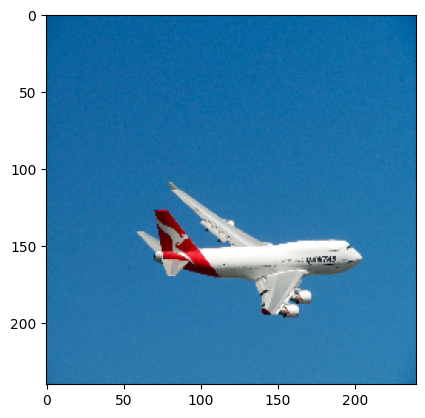

In [9]:
plt.imshow(original_image / 255.0)

In [10]:
adversarial_image = fgsm_attack_single_image(model, original_image, label=0, epsilon=4)

2025-02-02 15:38:35.423362: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 26784000 exceeds 10% of free system memory.
2025-02-02 15:38:35.462891: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 26784000 exceeds 10% of free system memory.
2025-02-02 15:38:35.506594: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 23846400 exceeds 10% of free system memory.


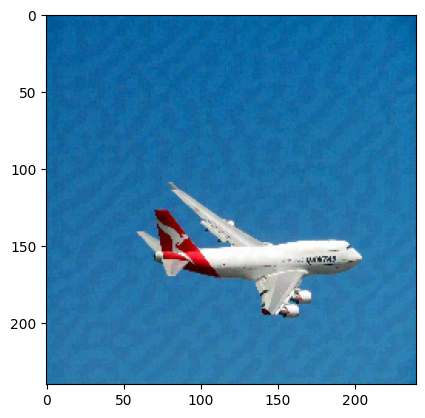

In [11]:
plt.imshow(adversarial_image / 255.0)

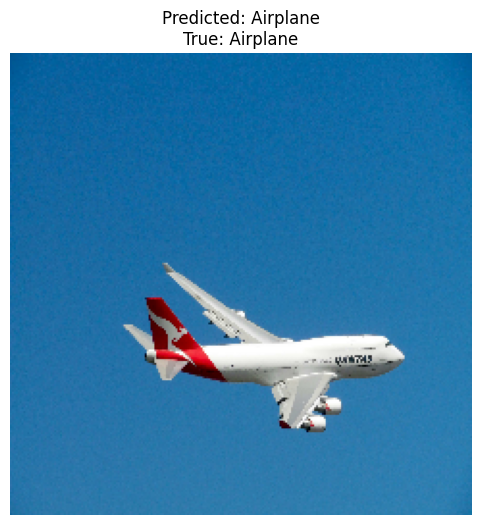

Top 1% Predictions:
  Airplane: 99.89%


In [14]:
utils.predict_and_plot(model, original_image, 0)

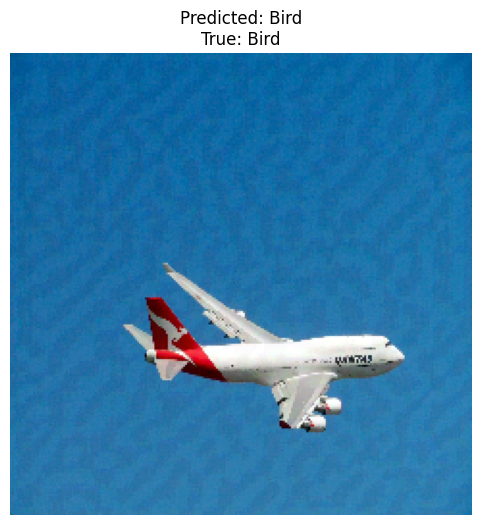

Top 1% Predictions:
  Bird: 99.63%


In [15]:
utils.predict_and_plot(model, adversarial_image, true_label=2)

In [22]:
adversarial_image_pgd = pgd_attack_single_image(model, original_image, label=0, epsilon=4, alpha=2, iterations=10)

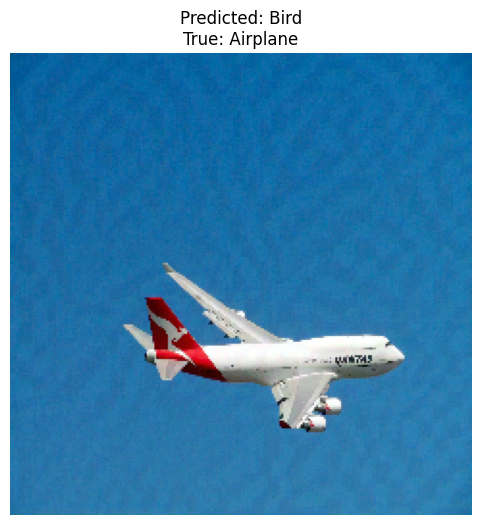

Top 1% Predictions:
  Bird: 100.00%


In [23]:
utils.predict_and_plot(model, adversarial_image_pgd, 0)

In [14]:
#adversarial_image_deepfool = deepfool_attack_single_image(model, original_image, num_classes=10, max_iter=50, overshoot=0.02)

In [15]:
def boundary_attack_single_image(model, original_image, adversarial_image, label, max_iter=1000, epsilon=0.01, step_size=0.01):
    """
    Perform the Boundary Attack on a single image.

    Args:
        model: The target model.
        original_image: The original input image.
        adversarial_image: The initial adversarial example.
        label: The true label of the original image.
        max_iter: Maximum number of iterations.
        epsilon: Perturbation size.
        step_size: Step size for moving closer to the original input.

    Returns:
        adversarial_image: The final adversarial example.
    """
    for i in range(max_iter):
        # 1. Generate a random perturbation
        perturbation = np.random.normal(scale=epsilon, size=original_image.shape)
        
        # 2. Perturb the adversarial example
        perturbed_image = adversarial_image + perturbation
        perturbed_image = np.clip(perturbed_image, 0, 255)  # Clip to valid pixel range
    
        # 3. Check if the perturbed example is adversarial
        if utils.is_adversarial(model, perturbed_image, label):
            # 4. Move closer to the original input
            last_updated_image = adversarial_image
            updated_image = adversarial_image + step_size * (original_image - adversarial_image)
            updated_image = np.clip(updated_image, 0, 255)  # Clip to valid pixel range
            # 5. Check if the updated example is still adversarial
            if utils.is_adversarial(model, updated_image, label):
                adversarial_image = updated_image  # Update the adversarial example
            else:
                print("the minimum perturbation is found")
                return last_updated_image
        else:
            print("the minimum perturbation is found")
            return last_updated_image
            
            
        
        # Print progress
        if i % 1 == 0:
            distance = np.linalg.norm(adversarial_image - original_image)
            print(f"Iteration {i}: Distance to original = {distance}")

    

In [16]:
#apply the boundary attack
adversarial_image_boundary = boundary_attack_single_image(model, original_image, adversarial_image_pgd, label=2, max_iter=1000, epsilon=0.01, step_size=0.1)

Iteration 0: Distance to original = 2090.1826171875
Iteration 1: Distance to original = 1881.1690673828125
Iteration 2: Distance to original = 1693.03076171875
Iteration 3: Distance to original = 1523.726806640625
Iteration 4: Distance to original = 1371.3394775390625
Iteration 5: Distance to original = 1234.2237548828125
Iteration 6: Distance to original = 1110.7806396484375
Iteration 7: Distance to original = 999.7146606445312
Iteration 8: Distance to original = 899.7518920898438
Iteration 9: Distance to original = 809.779541015625
Iteration 10: Distance to original = 728.7869873046875
Iteration 11: Distance to original = 655.9213256835938
Iteration 12: Distance to original = 590.32568359375
Iteration 13: Distance to original = 531.2918701171875
Iteration 14: Distance to original = 478.154296875
Iteration 15: Distance to original = 430.34332275390625
Iteration 16: Distance to original = 387.3114013671875
Iteration 17: Distance to original = 348.5797119140625
Iteration 18: Distance to

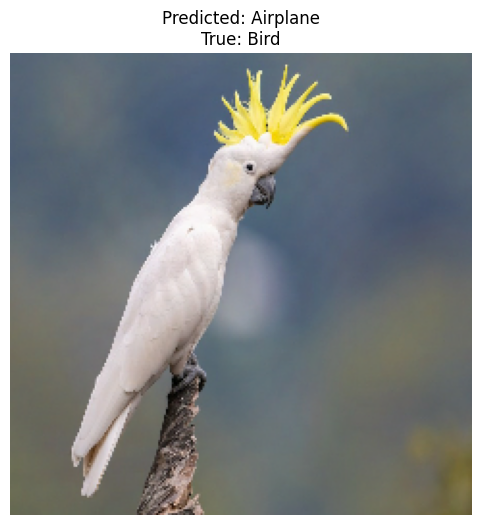

Top 1% Predictions:
  Airplane: 50.26%


In [17]:
utils.predict_and_plot(model, adversarial_image_boundary, 2)

In [18]:
#use very small step to make sure we are as close as possible to the original image
adversarial_image_boundary_AsCloseAsPossible = boundary_attack_single_image(model, original_image, adversarial_image_boundary, label=2, max_iter=1000, epsilon=0.01, step_size=0.001)

Iteration 0: Distance to original = 313.4024963378906
Iteration 1: Distance to original = 313.0937805175781
Iteration 2: Distance to original = 312.7828674316406
the minimum perturbation is found


In [21]:
import Utils as utils
#save the adversarial image
utils.save_image(adversarial_image_pgd, '../Adversarial_Images/pgd/airplan_pgd.png')

In [23]:
from blackbox import BlackBox

In [24]:
blackbox = BlackBox(model,(240,240),10)

In [26]:
prop = blackbox.predict(original_image)

ValueError: Input 0 of layer "EfficientNet_Model" is incompatible with the layer: expected shape=(None, 240, 240, 3), found shape=(1, 240, 3)

In [ ]:
box = BlackBox(model,(240,240),10)

In [ ]:
box.predict(original_image)

NameError: name 'resize' is not defined